In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [4]:
df = pd.read_csv("3-customersatisfaction.csv")

In [5]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [6]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [8]:
df.isnull().sum()

Customer Satisfaction    0
Incentive                0
dtype: int64

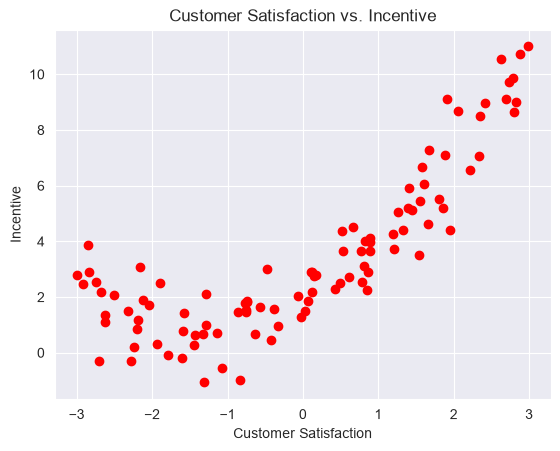

In [9]:
plt.scatter(df["Customer Satisfaction"], df["Incentive"],color="red")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.title("Customer Satisfaction vs. Incentive")
plt.show()

In [10]:
#dependent & independent features

In [11]:
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [12]:
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [14]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [15]:
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
regression = LinearRegression()

In [18]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.55]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.626
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[8.94]


In [19]:
##prediction

In [20]:
y_pred = regression.predict(X_test)

In [21]:
y_pred

array([ 4.65663741,  3.71913877,  1.64121789,  6.29646523,  3.46766736,
        5.7580845 ,  4.692485  ,  3.61616231,  5.62448003,  0.13472702,
        4.47909659,  4.8130839 ,  1.58319087,  0.30515983,  5.27634309,
        0.41711005, -0.7385295 , -0.32653914,  3.55906887,  1.19798631])

In [22]:
score = r2_score(y_test,y_pred)
print(score)
#0.7 çok kötü bir skor

0.2705652535622246


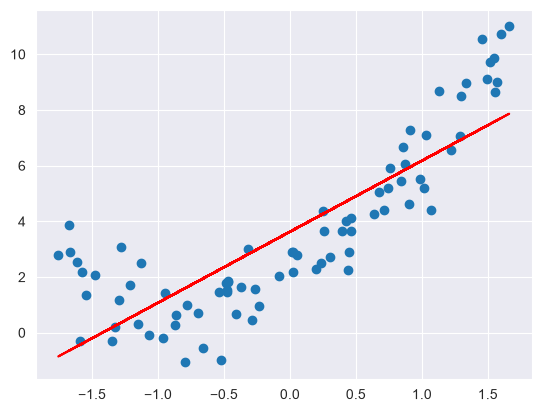

In [23]:
plt.plot(X_train,regression.predict(X_train), color="red")
plt.scatter(X_train, y_train)

In [24]:
#polynomial Regression

In [25]:
poly = PolynomialFeatures(degree=2,include_bias=True)

In [26]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [27]:
regression =LinearRegression()
regression.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0. ,2.64,1.55]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.077
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[9.02,8.06,0. ]"


In [28]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.7685687698788557


In [29]:
regression.coef_

array([0.        , 2.63871762, 1.54959954])

In [30]:
regression.intercept_

np.float64(2.076676429793282)

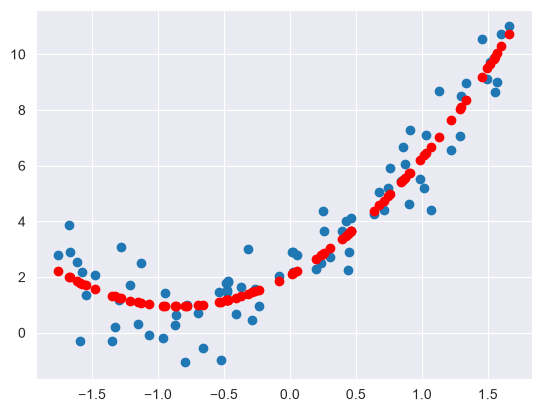

In [31]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression.predict(X_train_poly), color="red")
plt.show()

In [32]:
poly = PolynomialFeatures(degree=3,include_bias=True)


In [33]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [34]:
regression =LinearRegression()
regression.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. , 3.03, 1.53,-0.21]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.087
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[19.76, 8.11, 3.27, 0. ]"


In [35]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.7573443621401048


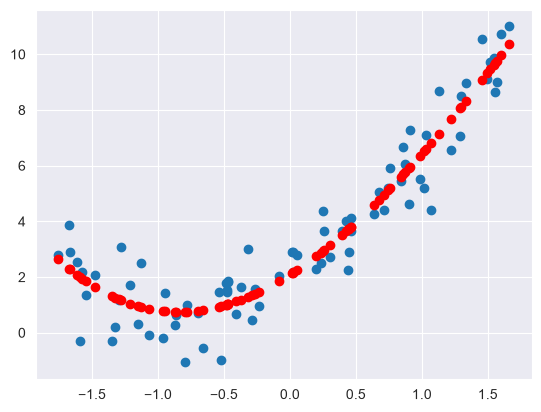

In [36]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression.predict(X_train_poly), color="red")
plt.show()

In [37]:
# new data

In [38]:
new_df = pd.read_csv("3-newdatas.csv")

In [39]:
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [40]:
new_df.rename(columns={"0": "Customer Satisfaction"},inplace=True)

In [41]:
new_df

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [42]:
X_new = new_df[["Customer Satisfaction"]]

In [43]:
X_new = scaler.fit_transform(X_new)

In [44]:
X_new_poly = poly.transform(X_new)

In [45]:
y_new = regression.predict(X_new_poly)

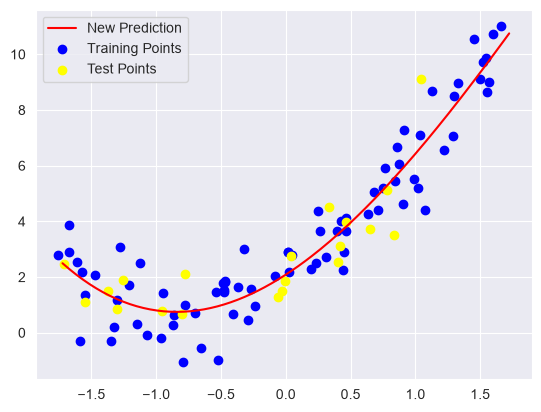

In [46]:
plt.plot(X_new,y_new,"r", label = "New Prediction")
plt.scatter(X_train,y_train,color="b", label = "Training Points")
plt.scatter(X_test,y_test, color="yellow", label = "Test Points")
plt.legend()
plt.show()

In [47]:
#pipeline

In [54]:
def poly_regression(degree):
    poly_features = PolynomialFeatures(degree=degree)
    lin_Reg = LinearRegression()
    scaler = StandardScaler()

    pipeline = Pipeline([
        ("std_scaler", scaler),
        ("poly_features",poly_features),
        ("lin_reg",lin_Reg)
    ])

    pipeline.fit(X_train,y_train)
    score = pipeline.score(X_test,y_test)
    score = float(score)
    print(f"R2 score in degree = {degree} : ",score)

    y_pred_new = pipeline.predict(X_new)

    plt.figure(figsize = (8,5))
    plt.plot(X_new,y_pred_new,"r", label = "New Prediction")
    plt.scatter(X_train,y_train,color="b", label = "Training Points")
    plt.scatter(X_test,y_test, color="yellow", label = "Test Points")

    plt.title(f"Polynomial Regression (Degree = {degree})")
    plt.legend()
    plt.grid(True)
    plt.show()


R2 score in degree = 2 :  0.7685687698788558


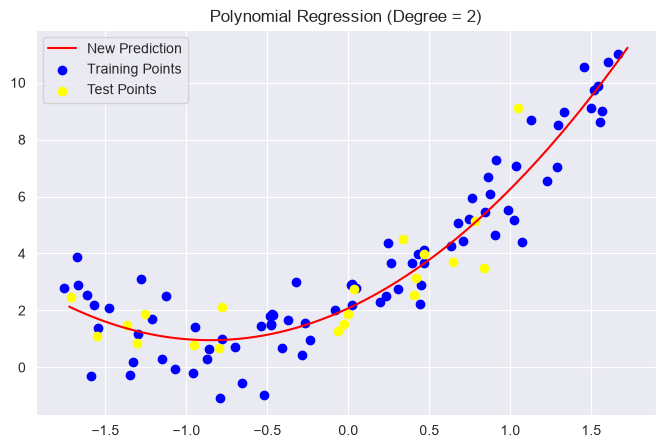

In [55]:
poly_regression(2)

R2 score in degree = 1 :  0.2705652535622246


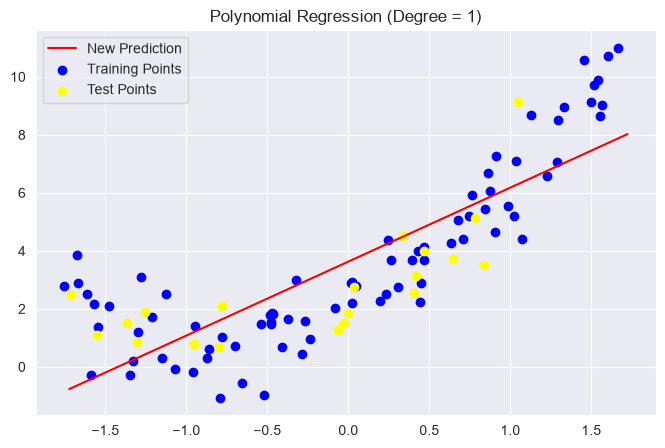

R2 score in degree = 2 :  0.7685687698788558


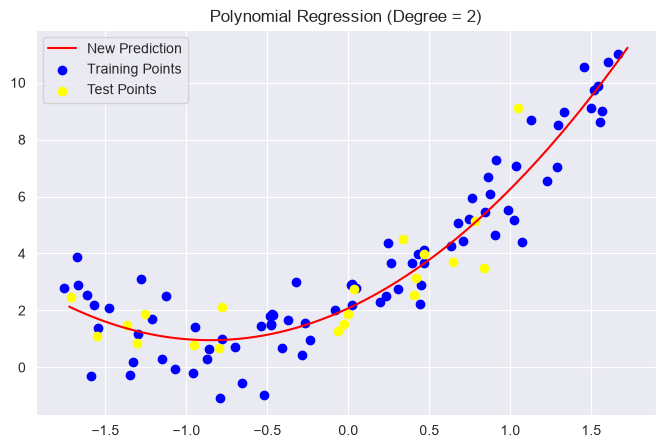

R2 score in degree = 3 :  0.757344362140105


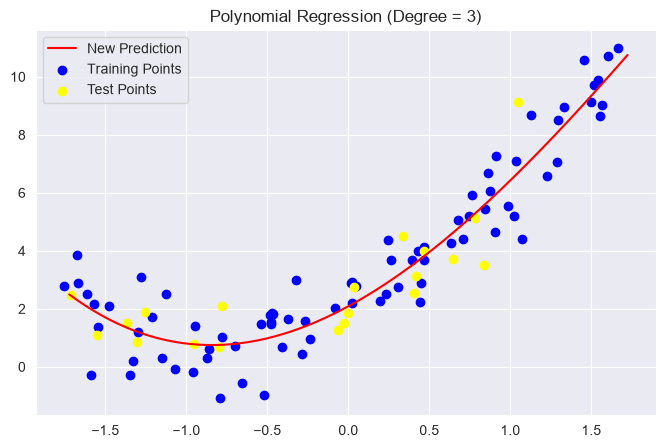

R2 score in degree = 4 :  0.7355034443260414


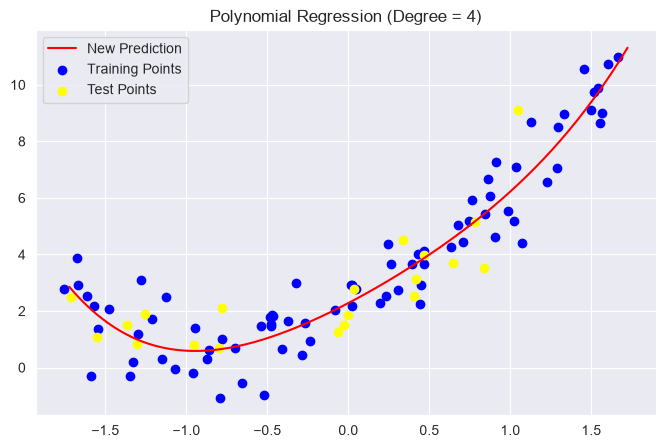

R2 score in degree = 5 :  0.7351244165095401


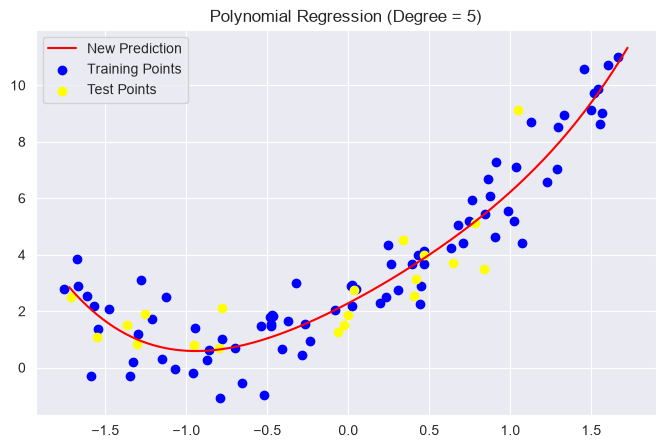

R2 score in degree = 6 :  0.7343590482133427


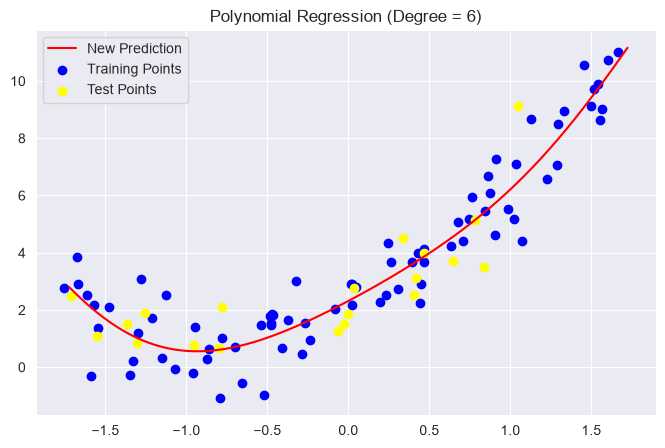

R2 score in degree = 7 :  0.7347819263549451


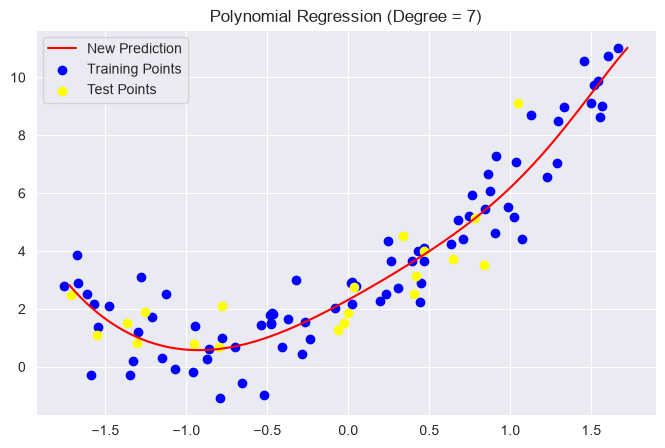

R2 score in degree = 8 :  0.7411422099998385


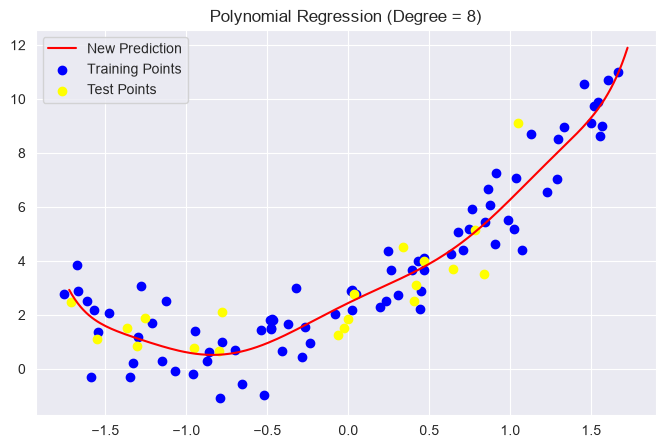

R2 score in degree = 9 :  0.7310763879815914


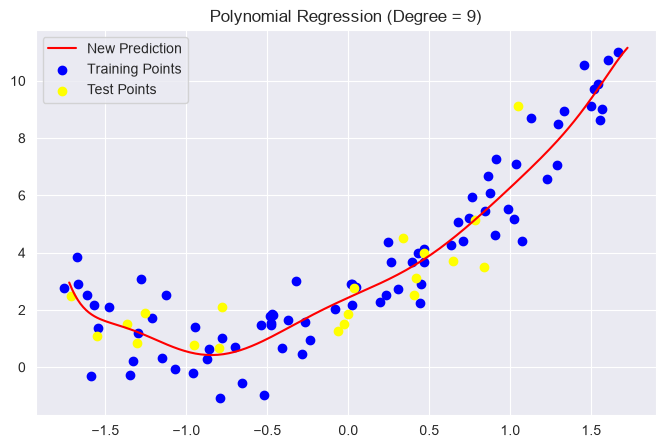

R2 score in degree = 10 :  0.7280578621232836


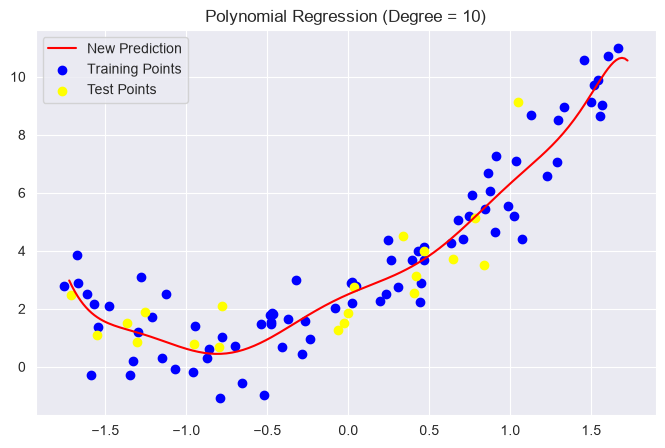

In [51]:
for degree in range(1,11):
    poly_regression(degree)


